In [176]:
import warnings
warnings.filterwarnings('ignore')
from sklearn import metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', size=14)
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn import metrics
import statsmodels.stats.api as sms
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import zscore
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [100]:
df = pd.read_csv('CO2_emission.csv')

In [101]:
df.head()

,Model_Year,Make,Model,Vehicle_Class,Engine_Size,Cylinders,Transmission,Fuel_Consumption_in_City(L/100 km),Fuel_Consumption_in_City_Hwy(L/100 km),Fuel_Consumption_comb(L/100km),CO2_Emissions,Smog_Level
0,2021,Acura,ILX,Compact,2.4,4,AM8,9.9,7.0,8.6,199,3
1,2021,Acura,NSX,Two-seater,3.5,6,AM9,11.1,10.8,11.0,256,3
2,2021,Acura,RDX SH-AWD,SUV: Small,2.0,4,AS10,11.0,8.6,9.9,232,6
3,2021,Acura,RDX SH-AWD A-SPEC,SUV: Small,2.0,4,AS10,11.3,9.1,10.3,242,6
4,2021,Acura,TLX SH-AWD,Compact,2.0,4,AS10,11.2,8.0,9.8,230,7


In [102]:
data = df.copy()

In [103]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 935 entries, 0 to 934
Data columns (total 12 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Model_Year                              935 non-null    int64  
 1   Make                                    935 non-null    object 
 2   Model                                   935 non-null    object 
 3   Vehicle_Class                           935 non-null    object 
 4   Engine_Size                             935 non-null    float64
 5   Cylinders                               935 non-null    int64  
 6   Transmission                            935 non-null    object 
 7   Fuel_Consumption_in_City(L/100 km)      935 non-null    float64
 8   Fuel_Consumption_in_City_Hwy(L/100 km)  935 non-null    float64
 9   Fuel_Consumption_comb(L/100km)          935 non-null    float64
 10  CO2_Emissions                           935 non-null    int64 

In [104]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Model_Year,935.0,2021.000000,0.000000,2021.0,2021.0,2021.0,2021.0,2021.0
Engine_Size,935.0,3.214866,1.388513,1.0,2.0,3.0,4.0,8.0
Cylinders,935.0,5.716578,1.977359,3.0,4.0,6.0,8.0,16.0
Fuel_Consumption_in_City(L/100 km),935.0,12.498610,3.487271,4.0,10.1,12.0,14.8,30.3
Fuel_Consumption_in_City_Hwy(L/100 km),935.0,9.306203,2.215819,3.9,7.7,9.0,10.8,20.9
Fuel_Consumption_comb(L/100km),935.0,11.060214,2.867028,4.0,9.1,10.7,13.1,26.1
CO2_Emissions,935.0,258.529412,64.442768,94.0,213.0,255.0,303.5,608.0
Smog_Level,935.0,4.726203,1.712127,1.0,3.0,5.0,6.0,7.0


In [105]:
data.shape

(935, 12)

In [106]:
data.isna().sum()

Model_Year                                0
Make                                      0
Model                                     0
Vehicle_Class                             0
Engine_Size                               0
Cylinders                                 0
Transmission                              0
Fuel_Consumption_in_City(L/100 km)        0
Fuel_Consumption_in_City_Hwy(L/100 km)    0
Fuel_Consumption_comb(L/100km)            0
CO2_Emissions                             0
Smog_Level                                0
dtype: int64

In [107]:
data.isnull().sum()

Model_Year                                0
Make                                      0
Model                                     0
Vehicle_Class                             0
Engine_Size                               0
Cylinders                                 0
Transmission                              0
Fuel_Consumption_in_City(L/100 km)        0
Fuel_Consumption_in_City_Hwy(L/100 km)    0
Fuel_Consumption_comb(L/100km)            0
CO2_Emissions                             0
Smog_Level                                0
dtype: int64

In [108]:
data.isin([0]).sum()

Model_Year                                0
Make                                      0
Model                                     0
Vehicle_Class                             0
Engine_Size                               0
Cylinders                                 0
Transmission                              0
Fuel_Consumption_in_City(L/100 km)        0
Fuel_Consumption_in_City_Hwy(L/100 km)    0
Fuel_Consumption_comb(L/100km)            0
CO2_Emissions                             0
Smog_Level                                0
dtype: int64

### Bivariate analysis

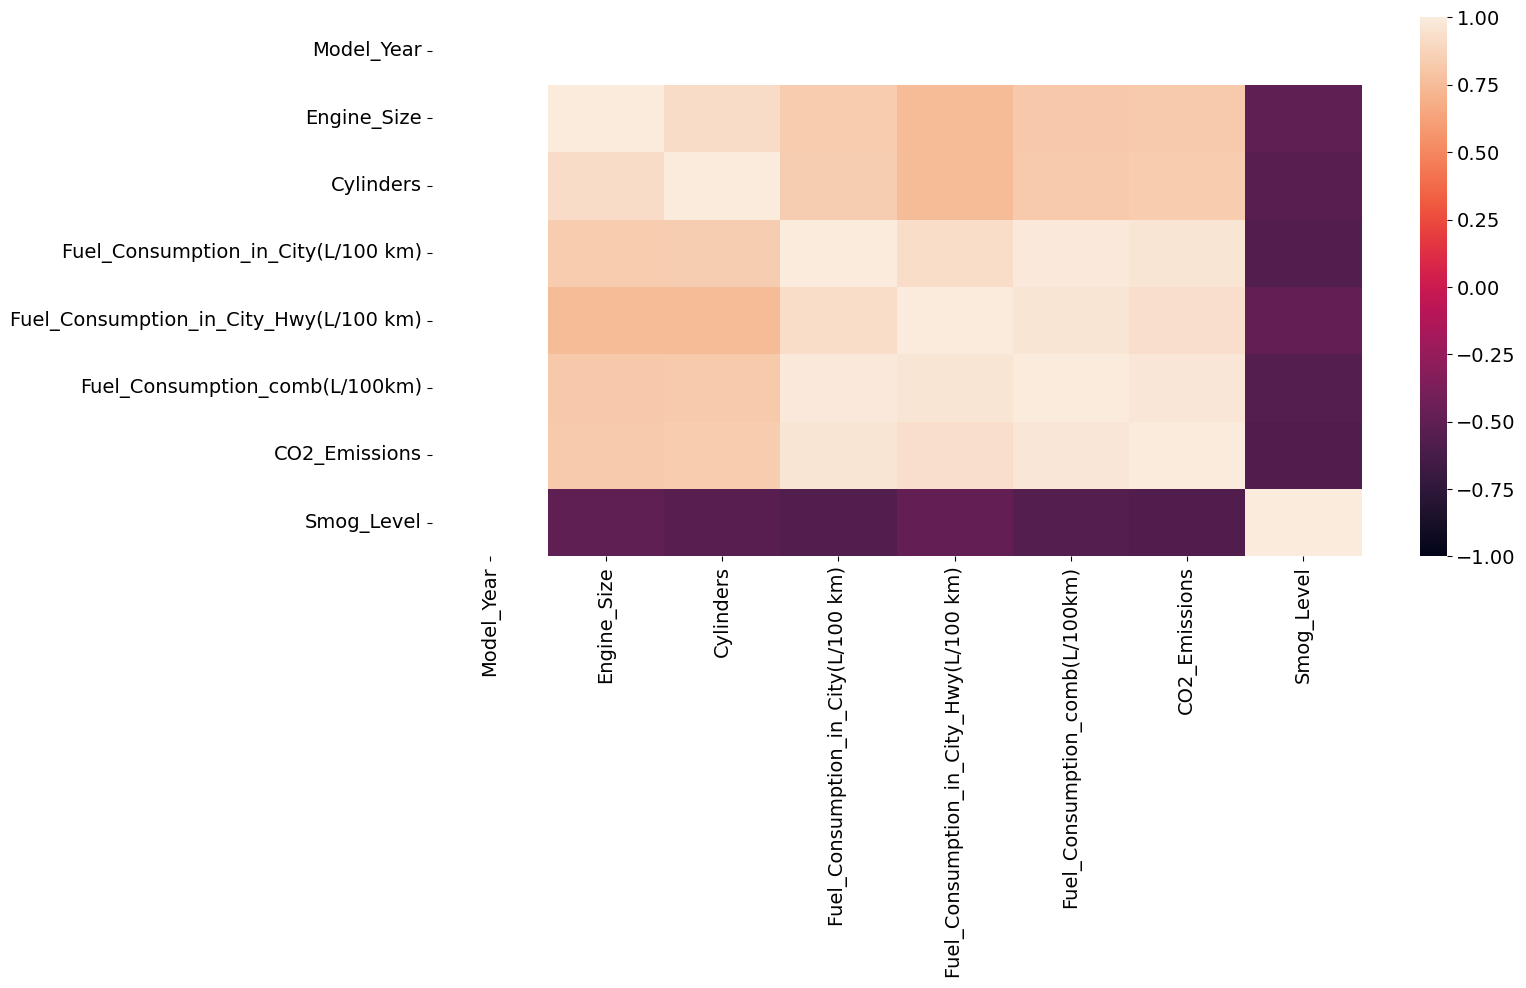

In [109]:
plt.figure(figsize=(15,7))
num_col = data.select_dtypes(include='number')
sns.heatmap(num_col.corr(), vmin=-1, vmax=1, annot=True)
plt.show();

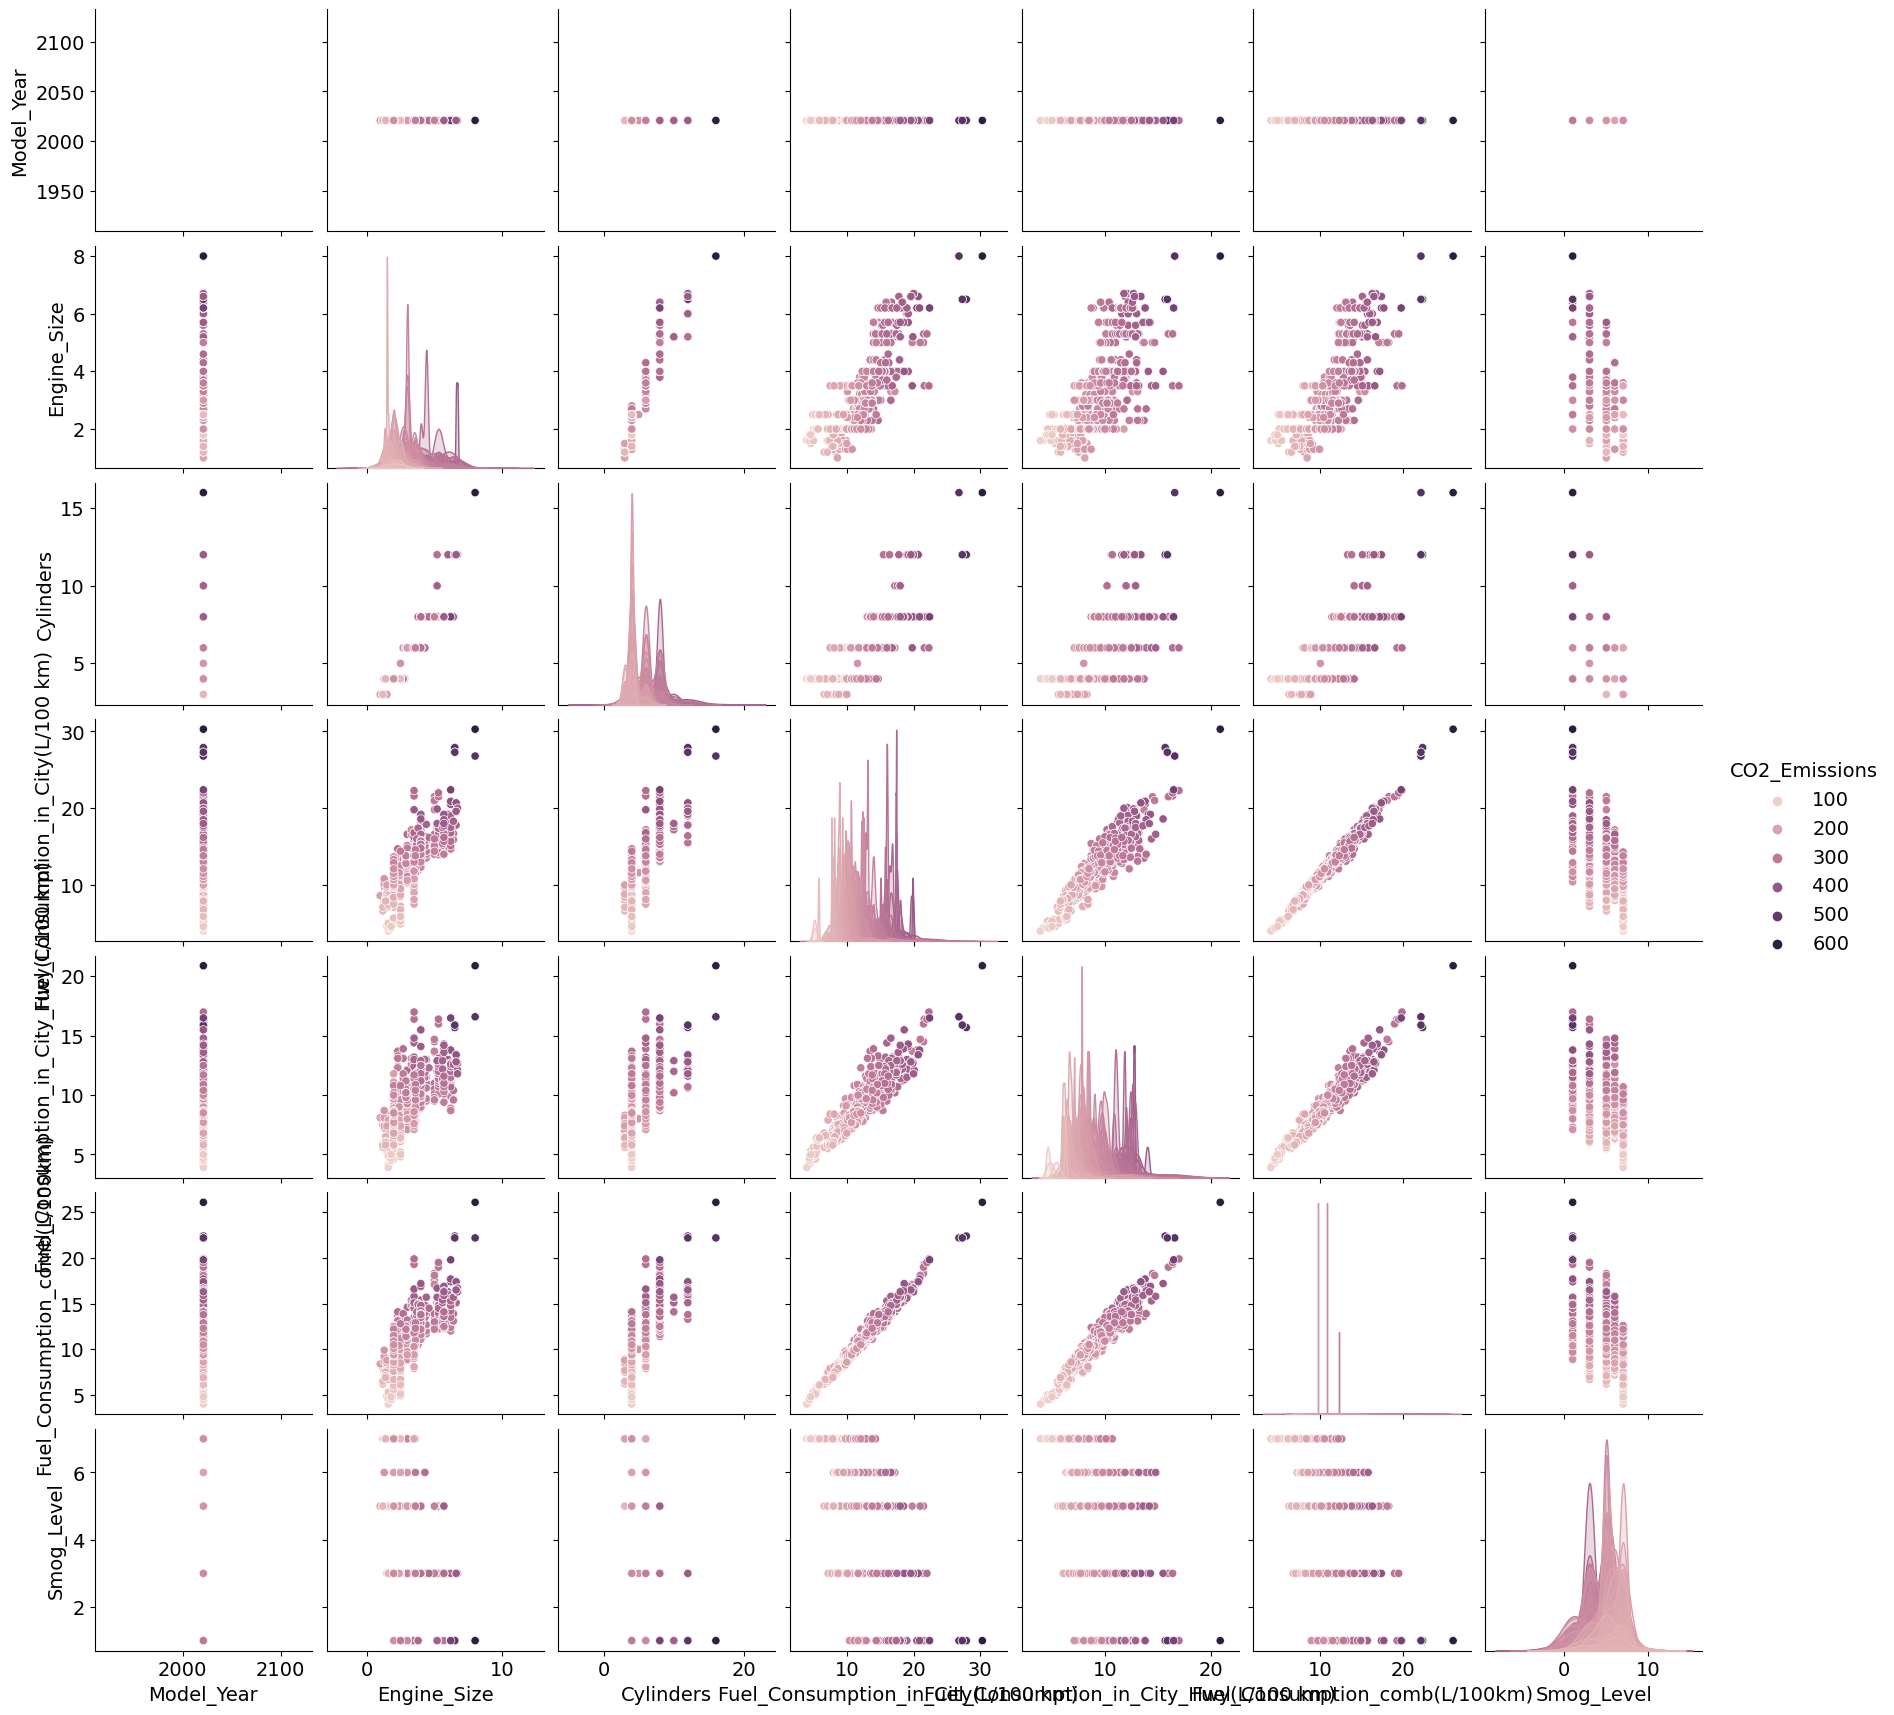

In [110]:
sns.pairplot(data, hue='CO2_Emissions')
plt.show();

In [111]:
for feature in data.columns:
    print(f'{feature}: {data[feature].unique()}\n')

Model_Year: [2021]

Make: ['Acura' 'Alfa Romeo' 'Aston Martin' 'Audi' 'Bentley' 'BMW' 'Bugatti'
 'Buick' 'Cadillac' 'Chevrolet' 'Chrysler' 'Dodge' 'FIAT' 'Ford' 'Genesis'
 'GMC' 'Honda' 'Hyundai' 'Infiniti' 'Jaguar' 'Jeep' 'Kia' 'Lamborghini'
 'Lexus' 'Lincoln' 'Maserati' 'Mazda' 'Mercedes-Benz' 'MINI' 'Mitsubishi'
 'Nissan' 'Porsche' 'Ram' 'Rolls-Royce' 'Subaru' 'Toyota' 'Volkswagen'
 'Volvo']

Model: ['ILX' 'NSX' 'RDX SH-AWD' 'RDX SH-AWD A-SPEC' 'TLX SH-AWD'
 'TLX SH-AWD A-SPEC' 'Giulia' 'Giulia AWD' 'Giulia Quadrifoglio' 'Stelvio'
 'Stelvio AWD' 'Stelvio AWD Quadrifoglio' 'DB11 V8' 'DB11 AMR'
 'DBS Superleggera' 'DBX V8' 'Vantage V8' 'A4 allroad 45 TFSI quattro'
 'A4 Sedan 40 TFSI quattro' 'A4 Sedan 45 TFSI quattro'
 'A5 Cabriolet 45 TFSI quattro' 'A5 Coupe 45 TFSI quattro'
 'A5 Sportback 45 TFSI quattro' 'A6 allroad 55 TFSI quattro'
 'A6 Sedan 45 TFSI quattro' 'A6 Sedan 55 TFSI quattro'
 'A7 Sportback 55 TFSI quattro' 'A8 L Sedan 55 TFSI quattro'
 'A8 L Sedan 60 TFSI quattro' 'Q3 4

### Data split into training and testing

In [112]:
x = data.drop(['CO2_Emissions'], axis=1)
y = data['CO2_Emissions']
x = sm.add_constant(x)
x = pd.get_dummies(x, drop_first=True)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.4, random_state = 1)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [113]:
x_train

array([[ 0.        ,  1.45343735,  1.18051912, ..., -0.07332356,
        -0.26572671, -0.08474272],
       [ 0.        , -0.17788677,  0.14166229, ..., -0.07332356,
        -0.26572671, -0.08474272],
       [ 0.        ,  1.24065594,  1.18051912, ..., -0.07332356,
        -0.26572671, -0.08474272],
       ...,
       [ 0.        ,  0.24767604,  0.14166229, ..., -0.07332356,
        -0.26572671, -0.08474272],
       [ 0.        ,  0.24767604,  0.14166229, ..., -0.07332356,
        -0.26572671, -0.08474272],
       [ 0.        ,  1.38251021,  2.21937595, ..., -0.07332356,
        -0.26572671, -0.08474272]])

In [114]:
x_test

array([[ 0.        ,  0.17674891,  0.14166229, ..., -0.07332356,
        -0.26572671, -0.08474272],
       [ 0.        , -0.24881391,  0.14166229, ..., -0.07332356,
        -0.26572671, -0.08474272],
       [ 0.        , -0.60344959, -0.89719453, ..., -0.07332356,
        -0.26572671, -0.08474272],
       ...,
       [ 0.        , -0.17788677,  0.14166229, ..., -0.07332356,
        -0.26572671, -0.08474272],
       [ 0.        , -0.88715813, -0.89719453, ..., -0.07332356,
        -0.26572671, -0.08474272],
       [ 0.        , -0.31974105, -0.89719453, ..., -0.07332356,
        -0.26572671, -0.08474272]])

### Decision Tree Regressor

In [115]:
df.head()

,Model_Year,Make,Model,Vehicle_Class,Engine_Size,Cylinders,Transmission,Fuel_Consumption_in_City(L/100 km),Fuel_Consumption_in_City_Hwy(L/100 km),Fuel_Consumption_comb(L/100km),CO2_Emissions,Smog_Level
0,2021,Acura,ILX,Compact,2.4,4,AM8,9.9,7.0,8.6,199,3
1,2021,Acura,NSX,Two-seater,3.5,6,AM9,11.1,10.8,11.0,256,3
2,2021,Acura,RDX SH-AWD,SUV: Small,2.0,4,AS10,11.0,8.6,9.9,232,6
3,2021,Acura,RDX SH-AWD A-SPEC,SUV: Small,2.0,4,AS10,11.3,9.1,10.3,242,6
4,2021,Acura,TLX SH-AWD,Compact,2.0,4,AS10,11.2,8.0,9.8,230,7


In [116]:
data1 = df.copy()

In [117]:
x_dt = data1.drop(['CO2_Emissions'], axis=1)
y_dt = data1['CO2_Emissions']
x_dt = pd.get_dummies(x_dt, drop_first=True).astype(int)
x_train_dt, x_test_dt, y_train_dt, y_test_dt = train_test_split(x_dt, y_dt, test_size = 0.3, random_state = 1)

In [118]:
dtree = DecisionTreeRegressor(random_state = 1)
dtree.fit(x_train_dt, y_train_dt)

DecisionTreeRegressor(random_state=1)

In [119]:
pred_train_dt = dtree.predict(x_train_dt)

In [120]:
rmse_train_dt = np.sqrt(((y_train_dt - pred_train_dt)**2).mean())
rmse_train_dt

0.2313370259423801

#### Predicitons on test set

In [121]:
pred_test_dt = dtree.predict(x_test_dt)

In [122]:
rmse_test = np.sqrt(((y_test_dt - pred_test_dt)**2).mean())
rmse_test

19.564679664933415

In [123]:
model_results = pd.DataFrame({'Model':['Decision Tree Regressor (Train)','Decision Tree Regressor (Test)'],'RMSE':[rmse_train_dt, rmse_test]})
model_results

,Model,RMSE
0,Decision Tree Regressor (Train),0.231337
1,Decision Tree Regressor (Test),19.564680


### Random Forest Regressor

In [124]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=1, n_jobs=-1)

In [125]:
rf_model.fit(x_train_dt, y_train_dt)

RandomForestRegressor(n_jobs=-1, random_state=1)

In [126]:
pred_train_rf = rf_model.predict(x_train_dt)

In [127]:
rmse_rf = np.sqrt(((y_train_dt - pred_train_rf)**2).mean())
rmse_rf

3.834436729089656

#### Predictions on test data

In [128]:
pred_test_rf = rf_model.predict(x_test_dt)

In [129]:
rmse_test_rf = np.sqrt(((y_test_dt - pred_test_rf)**2).mean())
rmse_test_rf

17.97188976610764

In [130]:
rf_results = pd.DataFrame({'Model':['Random Forest Regressor (Train)','Random Forest Regressor (Test)'],'RMSE':[rmse_rf, rmse_test_rf]})
model_results = pd.concat([model_results, rf_results], ignore_index=True)
model_results

,Model,RMSE
0,Decision Tree Regressor (Train),0.231337
1,Decision Tree Regressor (Test),19.564680
2,Random Forest Regressor (Train),3.834437
3,Random Forest Regressor (Test),17.971890


### KNN Regressor

In [133]:
model_knn = KNeighborsRegressor(n_neighbors=5)
model_knn.fit(x_train, y_train)

KNeighborsRegressor()

In [134]:
pred_train_knn = model_knn.predict(x_train)

In [135]:
rmse_train_knn = np.sqrt(((y_train - pred_train_knn)**2).mean())
rmse_train_knn

41.39342650199132

### Hyper tuning the model

In [136]:
param_grid = {'n_neighbors': range(1,21)}
grid = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, scoring ='neg_root_mean_squared_error')
grid.fit(x_train, y_train)
print(grid.best_params_)

{'n_neighbors': 4}


In [138]:
pred_train_ht_knn = grid.predict(x_train)

In [140]:
rmse_train_ht_knn = np.sqrt(((y_train - pred_train_ht_knn)**2).mean())
rmse_train_ht_knn

39.914034183194055

#### predicting on test data

In [142]:
pred_test_ht_knn = grid.predict(x_test)

In [143]:
rmse_test_ht_knn = np.sqrt(((y_test - pred_test_ht_knn)**2).mean())
rmse_test_ht_knn

55.22213890885112

In [145]:
results_knn = pd.DataFrame({'Model':['KNN Regressor (Train)','KNN Regressor (Test)'],'RMSE':[rmse_train_ht_knn, rmse_test_ht_knn]})
model_results = pd.concat([model_results, results_knn], ignore_index=True)
model_results

,Model,RMSE
0,Decision Tree Regressor (Train),0.231337
1,Decision Tree Regressor (Test),19.564680
2,Random Forest Regressor (Train),3.834437
3,Random Forest Regressor (Test),17.971890
4,KNN Regressor (Train),39.914034
5,KNN Regressor (Test),55.222139


### Support Vector Regressor

In [148]:
scaler_y = StandardScaler()
y_train_reshaped = y_train.values.reshape(-1, 1) if hasattr(y_train, 'values') else y_train.reshape(-1, 1)
y_train_scaled = scaler_y.fit_transform(y_train_reshaped).ravel()

In [158]:
svr = SVR(kernel='rbf', C=1, epsilon=0.1)
svr.fit(x_train, y_train_scaled)

SVR(C=1)

In [159]:
pred_train_svr = svr.predict(x_train)

In [160]:
rmse_train_svr = np.sqrt(((y_train - pred_train_svr)**2).mean())
rmse_train_svr

267.3044757518256

#### predictions on test data

In [161]:
pred_test_svr = svr.predict(x_test)

In [164]:
rmse_test_svr = np.sqrt(((y_test - pred_test_svr)**2).mean())
rmse_test_svr

264.61853880403345

In [165]:
results_svr = pd.DataFrame({'Model':['SVR (Train)', 'SVR (Test)'],'RMSE':[rmse_train_svr, rmse_test_svr]})
model_results = pd.concat([model_results, results_svr], ignore_index=True)
model_results

,Model,RMSE
0,Decision Tree Regressor (Train),0.231337
1,Decision Tree Regressor (Test),19.564680
2,Random Forest Regressor (Train),3.834437
3,Random Forest Regressor (Test),17.971890
4,KNN Regressor (Train),39.914034
5,KNN Regressor (Test),55.222139
6,SVR (Train),267.304476
7,SVR (Test),264.618539


### XGBoost

In [173]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=1)
xgb.fit(x_train_dt, y_train_dt)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=1, ...)

In [174]:
pred_train_xgb = xgb.predict(x_train_dt)

In [175]:
rmse_train_xgb = np.sqrt(((y_train_dt - pred_train_xgb)**2).mean())
rmse_train_xgb

2.7359845202231314

### tuning the XGB model

In [180]:
param_dist = {
    'n_estimators':[100,200,300],
    'learning_rate':[0.01, 0.05, 0.1, 0.2],
    'max_depth':[3,5,7,9],
    'subsample':[0.6,0.8,1],
    'colsample_bytree':[0.6,0.8,1],
    'gamma':[0,0.1,0.3],
    'reg_alpha':[0,0.1,1],
    'reg_lambda':[1,1.5,2]}
xgb1 = XGBRegressor(random_state=1)
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1)
random_search.fit(x_train_dt, y_train_dt)
print(random_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
{'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 1, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 1}


In [181]:
pred_train_tuned_xgb = random_search.predict(x_train_dt)

In [182]:
rmse_train_tuned_xgb = np.sqrt(((y_train_dt - pred_train_tuned_xgb)**2).mean())
rmse_train_tuned_xgb

2.6977280398161483

#### predictions on test data

In [183]:
pred_test_tuned_xgb = random_search.predict(x_test_dt)

In [184]:
rmse_test_tuned_xgb = np.sqrt(((y_test_dt - pred_test_tuned_xgb)**2).mean())
rmse_test_tuned_xgb

17.0853978724676

In [185]:
xgb_results = pd.DataFrame({'Model':['XGB (Train)','XGB (Test)'],'RMSE':[rmse_train_tuned_xgb, rmse_test_tuned_xgb]})
model_results = pd.concat([model_results, xgb_results], ignore_index=True)
model_results

,Model,RMSE
0,Decision Tree Regressor (Train),0.231337
1,Decision Tree Regressor (Test),19.564680
2,Random Forest Regressor (Train),3.834437
3,Random Forest Regressor (Test),17.971890
4,KNN Regressor (Train),39.914034
5,KNN Regressor (Test),55.222139
6,SVR (Train),267.304476
7,SVR (Test),264.618539
8,XGB (Train),2.697728
9,XGB (Test),17.085398
